#regression puzzle

> Blockquote toevoegen



##Exploration of the data

Saving E.xlsx to E (2).xlsx
Saving N.xlsx to N (2).xlsx

Processing file: E (2).xlsx
Sheets: ['0', '1', '2', '3', '4', '5']

--- Sheet: 0 ---


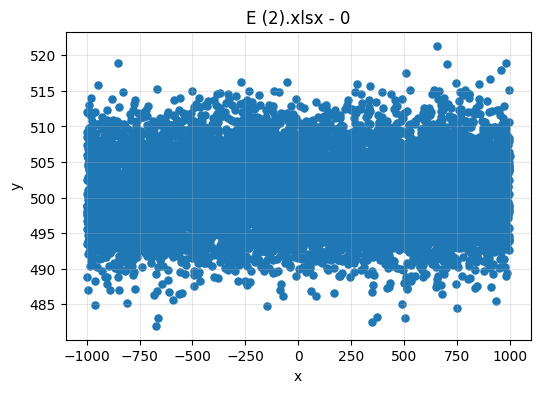

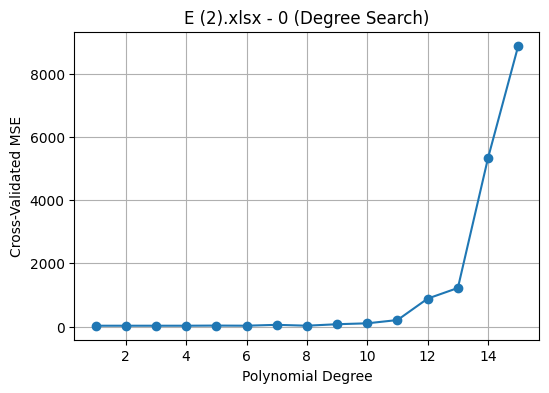

Best degree: 1

--- Sheet: 1 ---


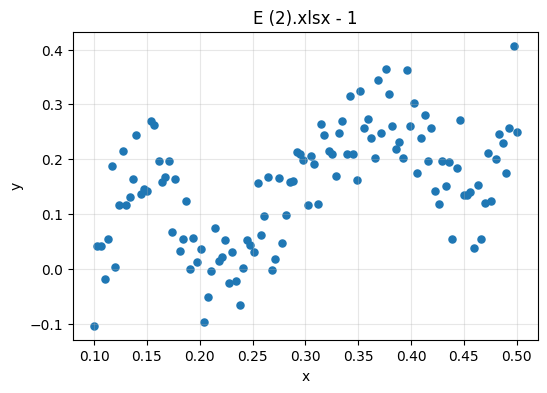

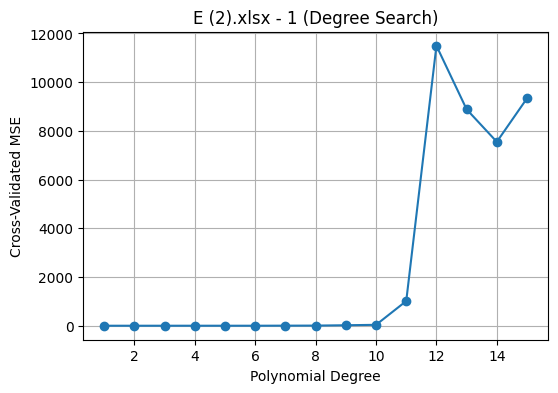

Best degree: 1

--- Sheet: 2 ---


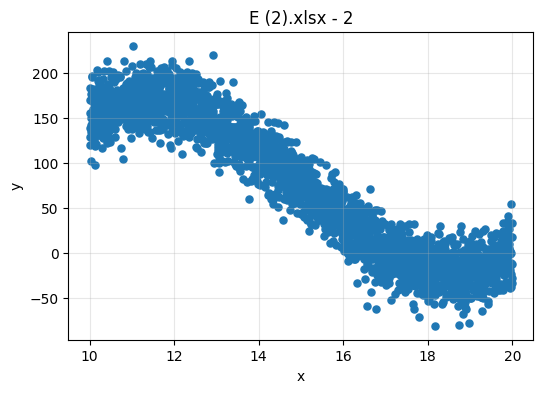

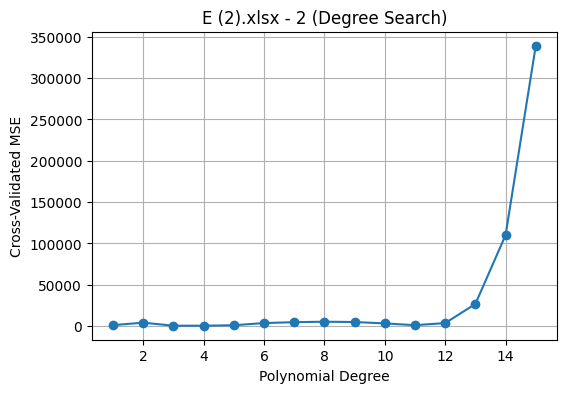

Best degree: 3

--- Sheet: 3 ---


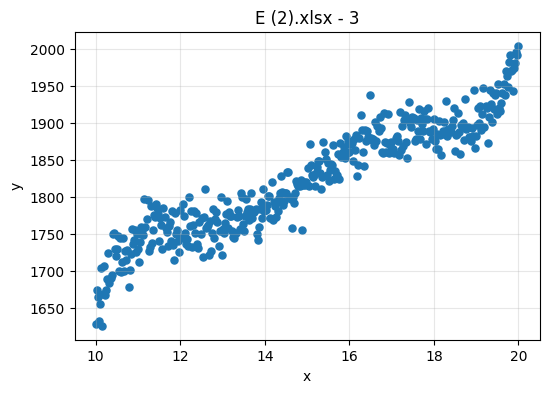

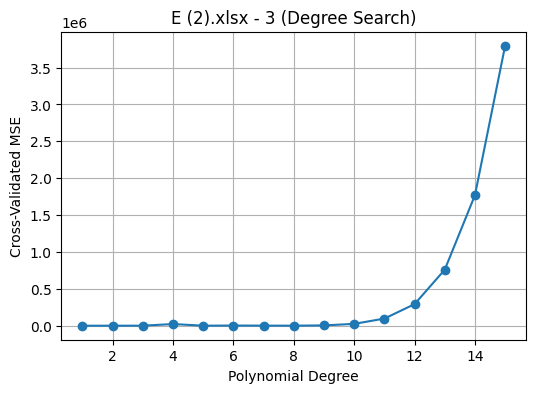

Best degree: 1

--- Sheet: 4 ---


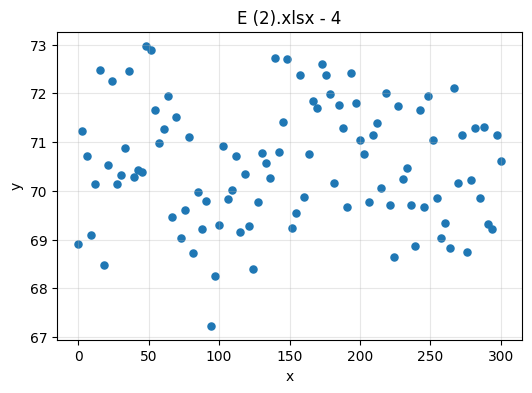

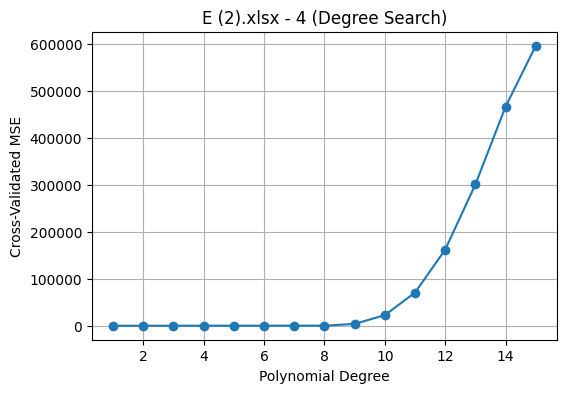

Best degree: 1

--- Sheet: 5 ---


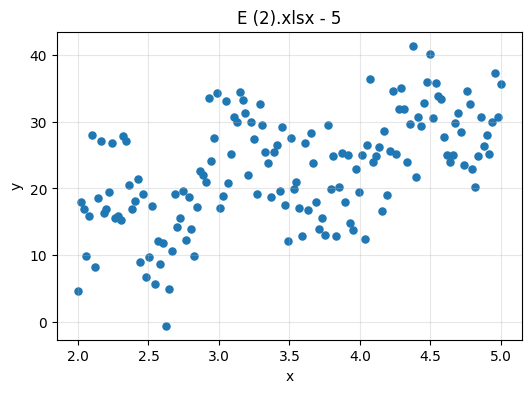

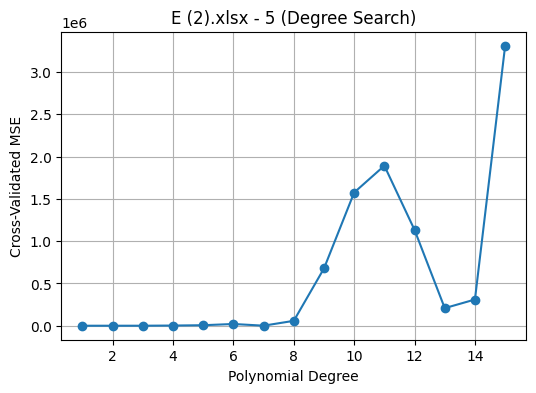

Best degree: 1

Processing file: N (2).xlsx
Sheets: ['0', '1', '2', '3', '4', '5']

--- Sheet: 0 ---


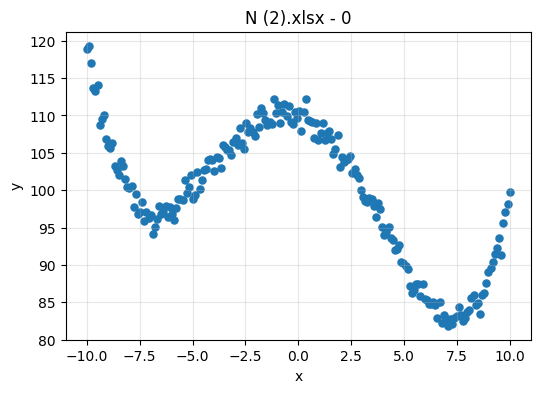

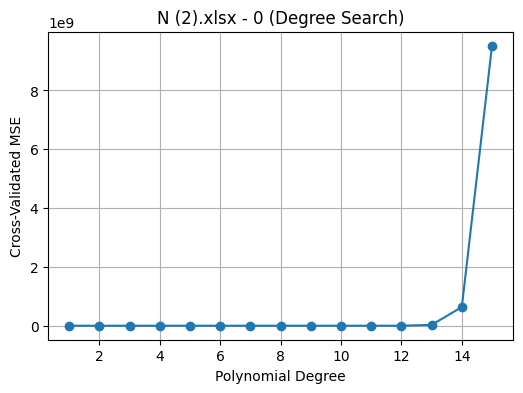

Best degree: 4

--- Sheet: 1 ---


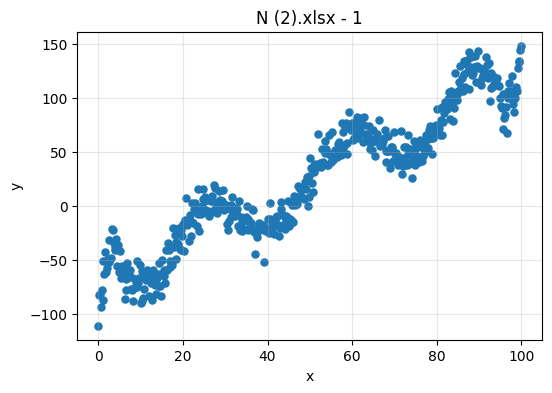

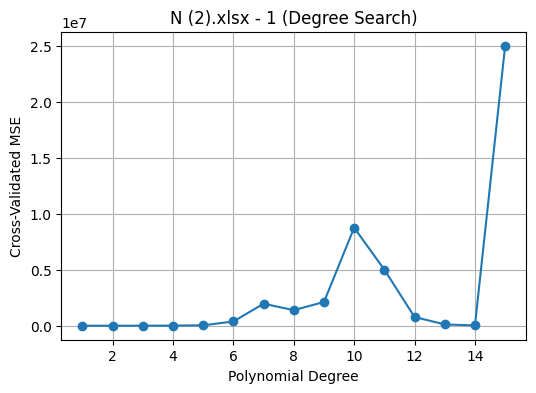

Best degree: 1

--- Sheet: 2 ---


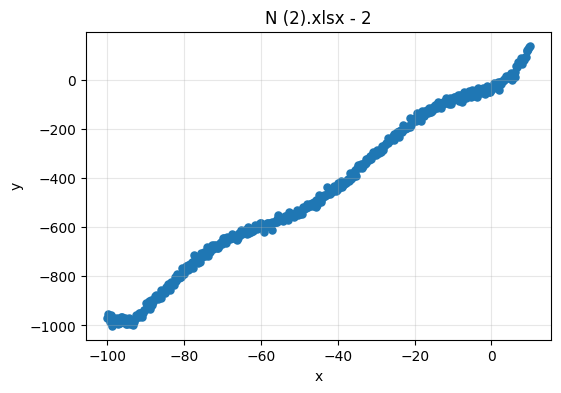

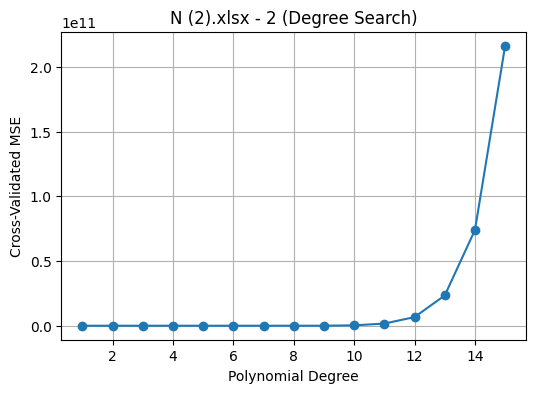

Best degree: 6

--- Sheet: 3 ---


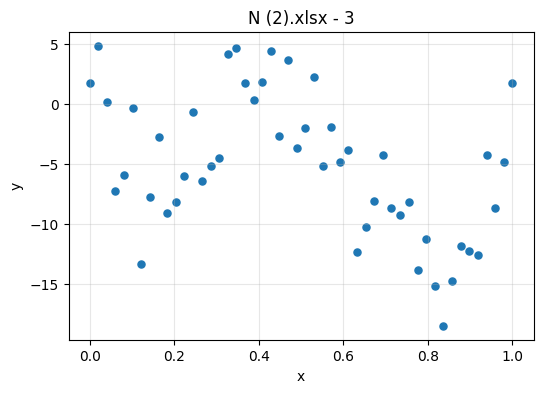

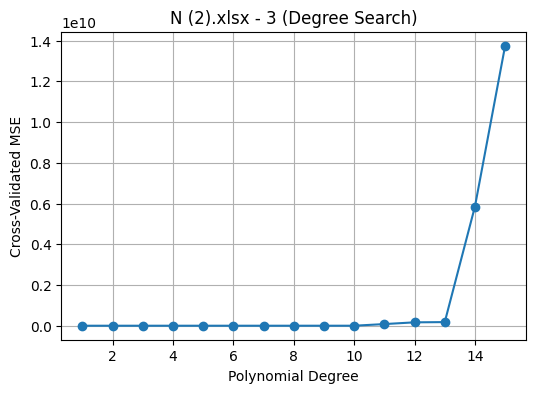

Best degree: 1

--- Sheet: 4 ---


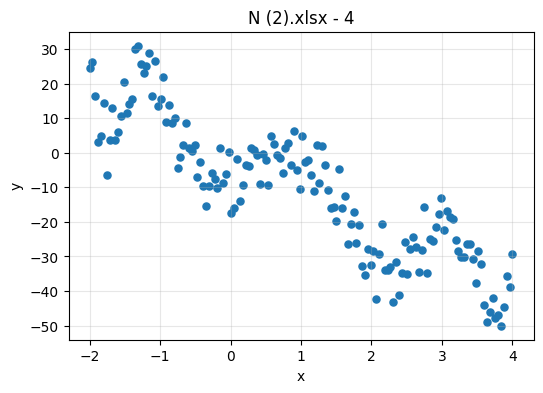

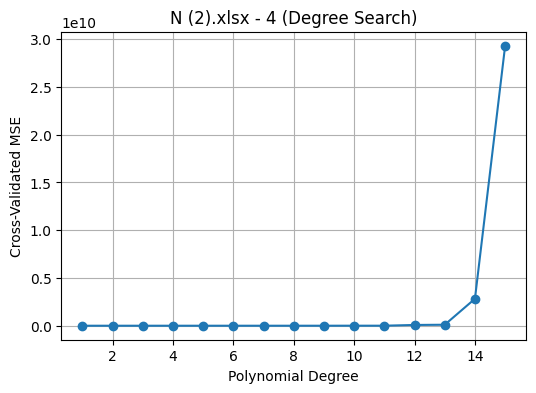

Best degree: 1

--- Sheet: 5 ---


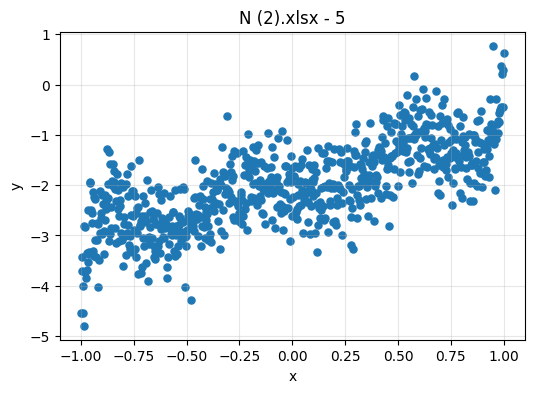

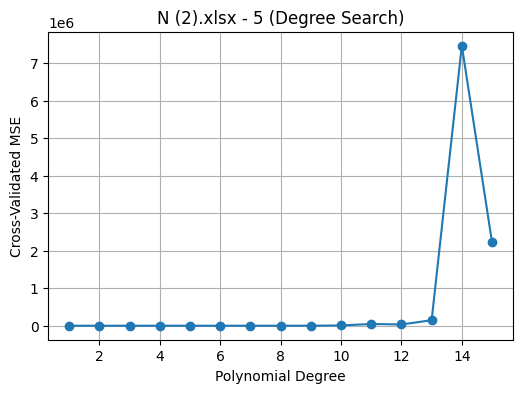

Best degree: 1

FINAL DEGREE RESULTS

 E (2).xlsx
0: 1
1: 1
2: 3
3: 1
4: 1
5: 1

 N (2).xlsx
0: 4
1: 1
2: 6
3: 1
4: 1
5: 1


In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# =========================
# Upload files
# =========================
uploaded = files.upload()

# =========================
# Function to process Excel
# =========================
def process_excel(filename):

    print("\n=============================")
    print(f"Processing file: {filename}")
    print("=============================")

    excel = pd.ExcelFile(io.BytesIO(uploaded[filename]))
    sheets = excel.sheet_names

    print("Sheets:", sheets)

    results = {}

    for sheet in sheets:

        print(f"\n--- Sheet: {sheet} ---")

        df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name=sheet)

        # Keep numeric columns
        df = df.select_dtypes(include=[np.number])

        if df.shape[1] < 2:
            print("Not enough numeric columns to analyze")
            continue

        # Assume first column = x, second = y
        x = df.iloc[:,0].values.reshape(-1,1)
        y = df.iloc[:,1].values

        # Remove NaN / inf
        mask = np.isfinite(x.flatten()) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        # Plot dataset
        plt.figure(figsize=(6,4))
        plt.scatter(x, y, s=26)
        plt.title(f"{filename} - {sheet}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.grid(True, alpha=0.3)
        plt.show()

        # Polynomial degree search
        degrees = range(1,16)
        errors = []

        for d in degrees:

            poly = PolynomialFeatures(degree=d)
            X_poly = poly.fit_transform(x)

            model = LinearRegression()

            scores = cross_val_score(
                model,
                X_poly,
                y,
                scoring="neg_mean_squared_error",
                cv=5
            )

            mse = -scores.mean()
            errors.append(mse)

        best_degree = degrees[np.argmin(errors)]
        results[sheet] = best_degree

        # Plot error curve
        plt.figure(figsize=(6,4))
        plt.plot(degrees, errors, marker='o')
        plt.title(f"{filename} - {sheet} (Degree Search)")
        plt.xlabel("Polynomial Degree")
        plt.ylabel("Cross-Validated MSE")
        plt.grid(True)
        plt.show()

        print("Best degree:", best_degree)

    return results


# =========================
# Run for both files
# =========================
all_results = {}

for filename in uploaded.keys():
    res = process_excel(filename)
    all_results[filename] = res


print("\n=============================")
print("FINAL DEGREE RESULTS")
print("=============================")

for file, sheets in all_results.items():
    print("\n", file)
    for sheet, deg in sheets.items():
        print(f"{sheet}: {deg}")

##polynomial regression analysis

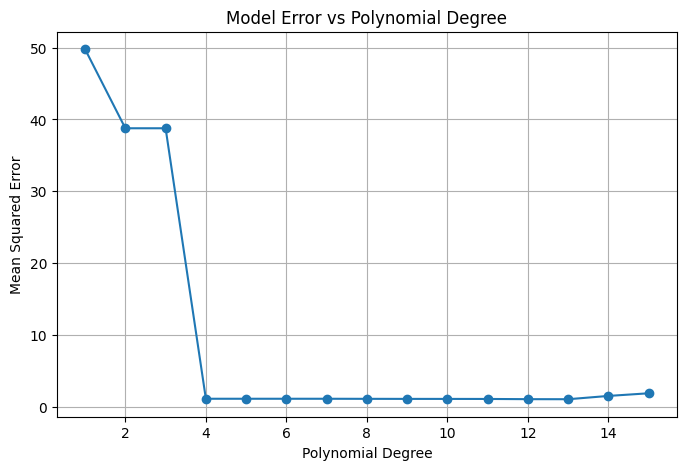

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Extract values
X = N_clean[['x']].values
y = N_clean['y'].values

degrees = range(1, 16)
mse_list = []

for d in degrees:

    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    mse = mean_squared_error(y, y_pred)
    mse_list.append(mse)

# Plot MSE vs degree
plt.figure(figsize=(8,5))
plt.plot(degrees, mse_list, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Model Error vs Polynomial Degree")
plt.grid(True)
plt.show()

we can see the best degree to achieve an apropriate fitting is 4.

### searching for the best degree using cross validationn (folds)

for N

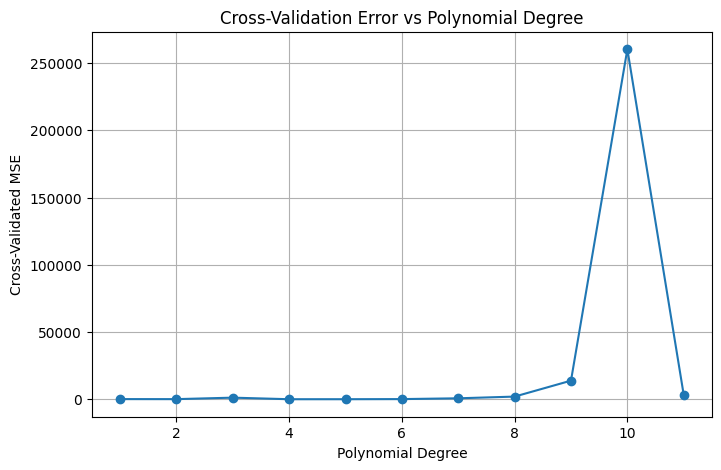

Best degree (cross-validation): 4


In [ ]:
from sklearn.model_selection import cross_val_score

degrees = range(1, 12)
cv_errors = []

for d in degrees:

    poly = PolynomialFeatures(degree=d)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_poly,
        y,
        scoring="neg_mean_squared_error",
        cv=5
    )

    mse = -scores.mean()
    cv_errors.append(mse)

plt.figure(figsize=(8,5))
plt.plot(degrees, cv_errors, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Cross-Validated MSE")
plt.title("Cross-Validation Error vs Polynomial Degree")
plt.grid(True)
plt.show()

best_degree = degrees[np.argmin(cv_errors)]
print("Best degree (cross-validation):", best_degree)

for E

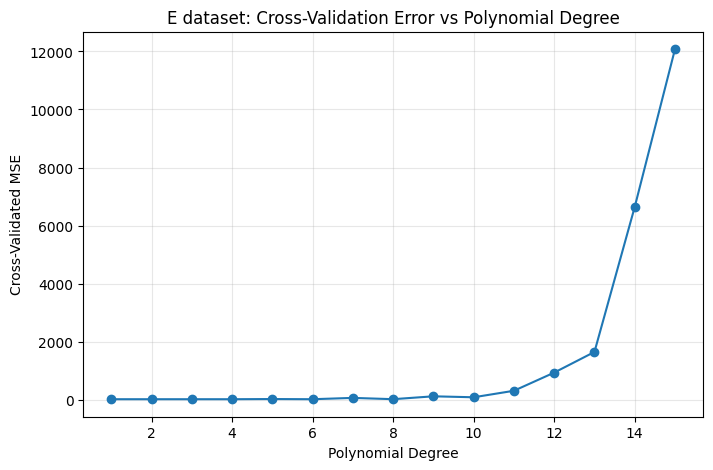

Best degree for E: 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Use cleaned E dataset
X_E = E_clean[['x']].values
y_E = E_clean['y'].values

degrees = range(1, 16)
cv_errors_E = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly_E = poly.fit_transform(X_E)

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_poly_E,
        y_E,
        scoring='neg_mean_squared_error',
        cv=5
    )

    mse = -scores.mean()
    cv_errors_E.append(mse)

plt.figure(figsize=(8,5))
plt.plot(degrees, cv_errors_E, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Cross-Validated MSE")
plt.title("E dataset: Cross-Validation Error vs Polynomial Degree")
plt.grid(True, alpha=0.3)
plt.show()

best_degree_E = degrees[np.argmin(cv_errors_E)]
print("Best degree for E:", best_degree_E)


Saving E.xlsx to E (7).xlsx
Saving N.xlsx to N (7).xlsx

FILE: E (7).xlsx
Sheets: ['0', '1', '2', '3', '4', '5']

E (7).xlsx / sheet 0
Chosen degree counts across repeats: {1: 14, 3: 5, 2: 9, 5: 1, 4: 1}
Stable degree (most often chosen): 1
Best degree by average held-out validation MSE: 3
Average held-out validation MSE per degree:
  degree 1: 25.129557
  degree 2: 25.128488
  degree 3: 25.127219
  degree 4: 25.132032
  degree 5: 25.135021
  degree 6: 25.139686
  degree 7: 25.146994
  degree 8: 25.156028
  degree 9: 25.160859


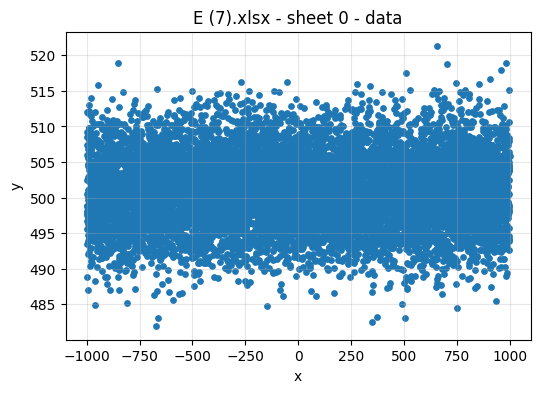

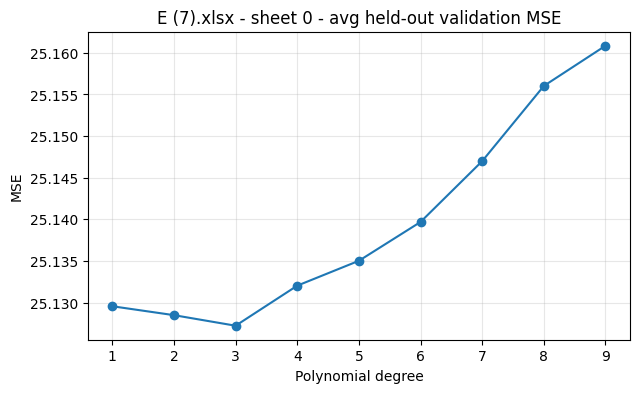

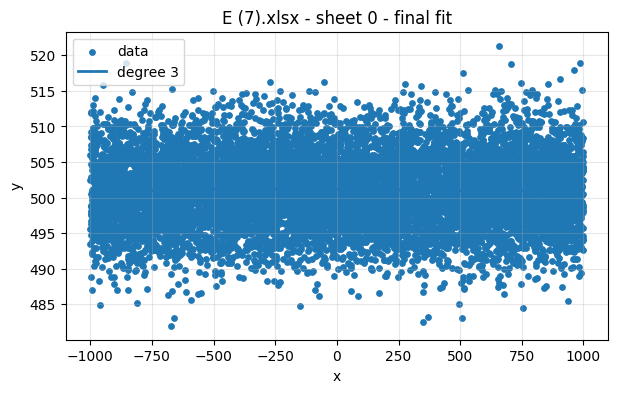


E (7).xlsx / sheet 1
Chosen degree counts across repeats: {5: 12, 6: 9, 8: 3, 9: 6}
Stable degree (most often chosen): 5
Best degree by average held-out validation MSE: 5
Average held-out validation MSE per degree:
  degree 1: 0.008946
  degree 2: 0.009085
  degree 3: 0.008359
  degree 4: 0.008866
  degree 5: 0.003633
  degree 6: 0.003660
  degree 7: 0.003867
  degree 8: 0.003872
  degree 9: 0.003821


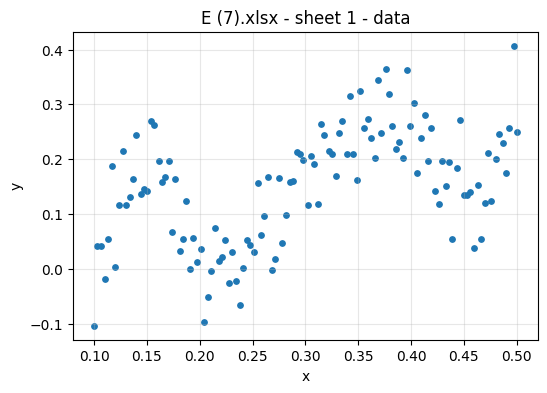

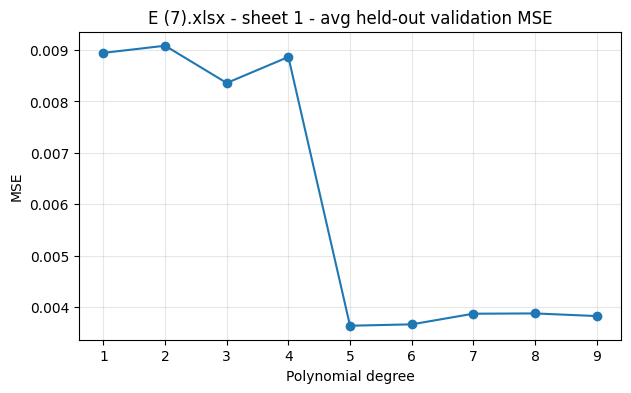

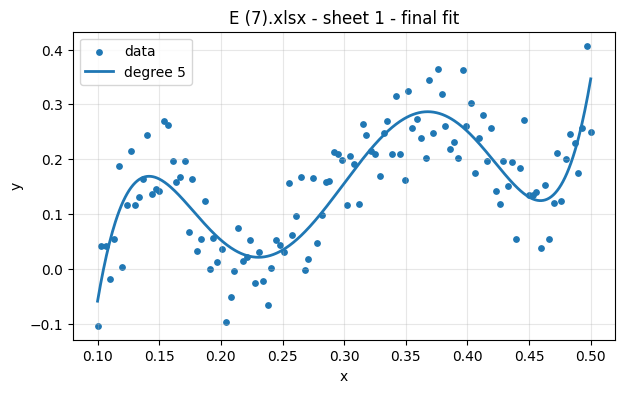


E (7).xlsx / sheet 2
Chosen degree counts across repeats: {3: 28, 5: 1, 4: 1}
Stable degree (most often chosen): 3
Best degree by average held-out validation MSE: 3
Average held-out validation MSE per degree:
  degree 1: 727.406838
  degree 2: 728.480801
  degree 3: 377.025553
  degree 4: 377.389697
  degree 5: 377.642430
  degree 6: 378.176445
  degree 7: 378.348209
  degree 8: 378.337307
  degree 9: 377.831560


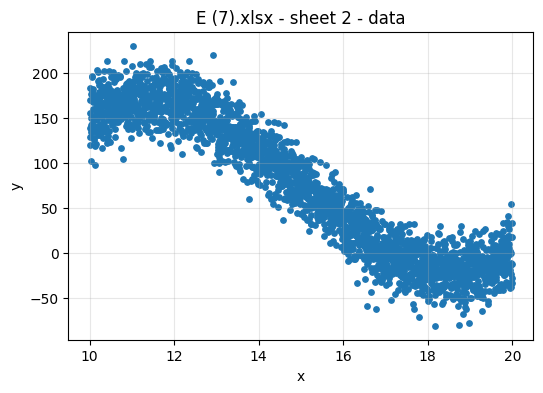

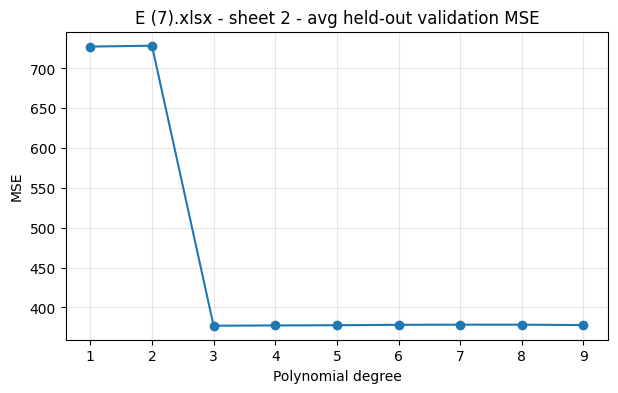

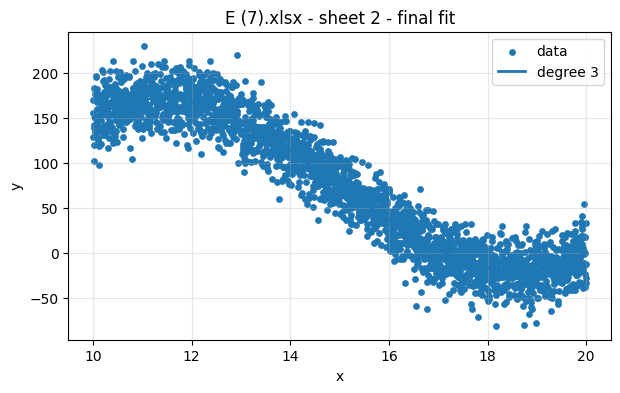


E (7).xlsx / sheet 3
Chosen degree counts across repeats: {5: 27, 6: 3}
Stable degree (most often chosen): 5
Best degree by average held-out validation MSE: 5
Average held-out validation MSE per degree:
  degree 1: 647.504776
  degree 2: 652.075711
  degree 3: 655.974952
  degree 4: 666.586792
  degree 5: 410.300352
  degree 6: 413.166139
  degree 7: 414.614984
  degree 8: 416.591656
  degree 9: 419.354541


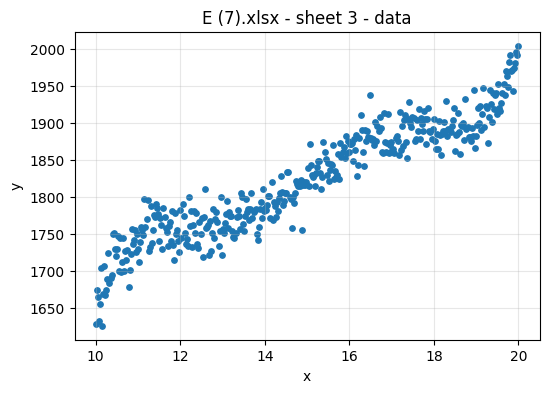

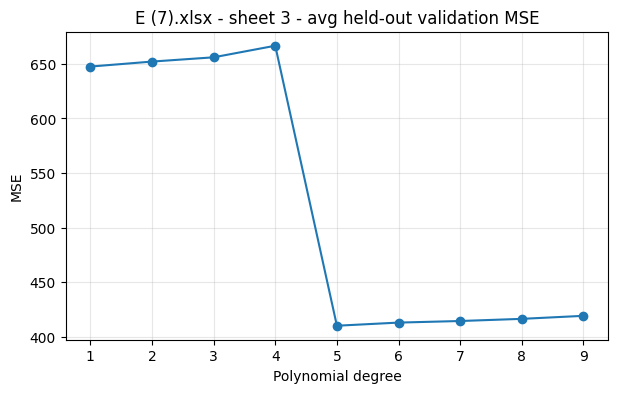

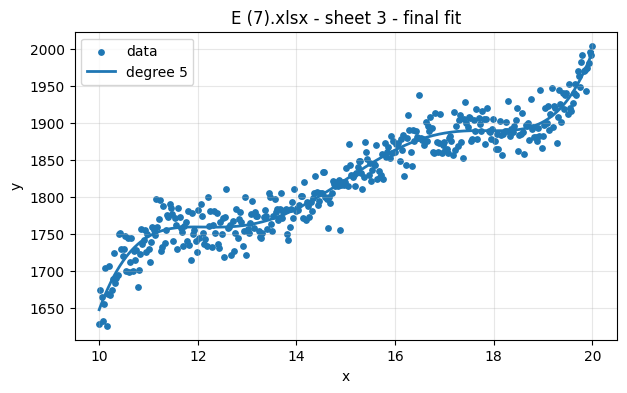


E (7).xlsx / sheet 4
Chosen degree counts across repeats: {5: 9, 8: 9, 6: 5, 1: 1, 7: 3, 9: 3}
Stable degree (most often chosen): 5
Best degree by average held-out validation MSE: 5
Average held-out validation MSE per degree:
  degree 1: 1.478630
  degree 2: 1.503114
  degree 3: 1.524723
  degree 4: 1.576967
  degree 5: 1.333170
  degree 6: 1.485304
  degree 7: 1.457105
  degree 8: 1.375933
  degree 9: 1.461913


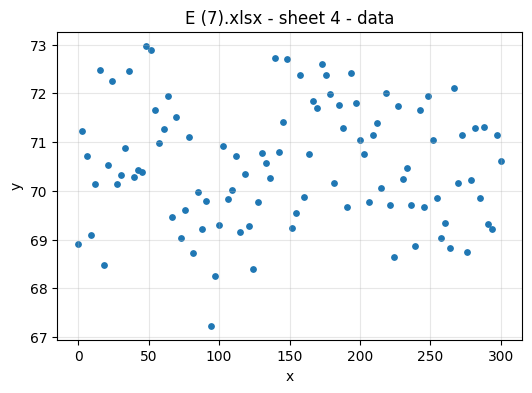

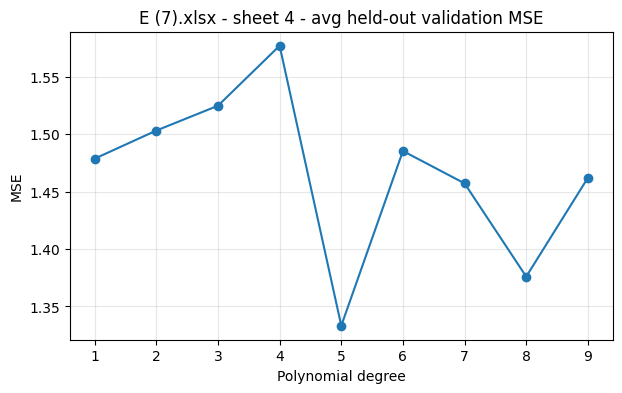

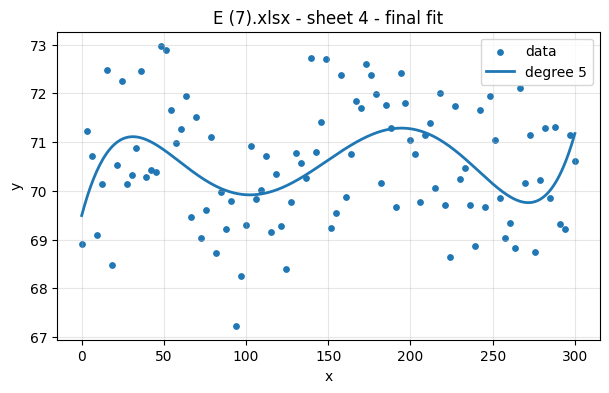


E (7).xlsx / sheet 5
Chosen degree counts across repeats: {7: 23, 8: 3, 9: 4}
Stable degree (most often chosen): 7
Best degree by average held-out validation MSE: 7
Average held-out validation MSE per degree:
  degree 1: 46.434471
  degree 2: 46.813447
  degree 3: 47.582552
  degree 4: 48.974676
  degree 5: 49.359740
  degree 6: 50.193158
  degree 7: 32.799038
  degree 8: 33.528943
  degree 9: 33.096727


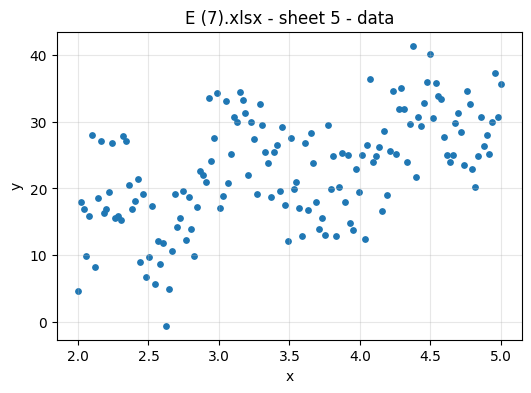

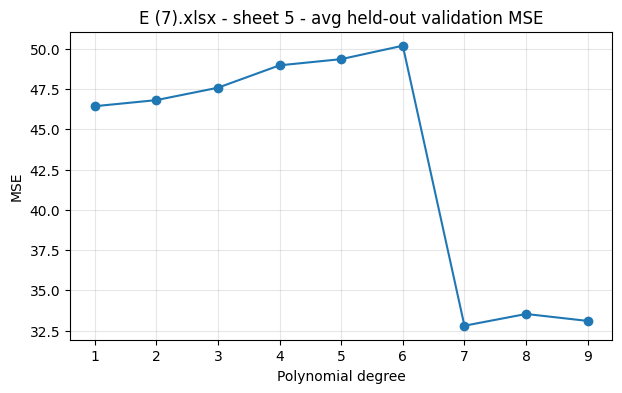

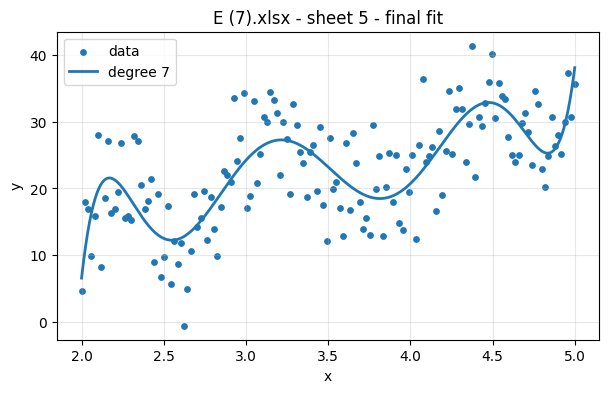


FILE: N (7).xlsx
Sheets: ['0', '1', '2', '3', '4', '5']

N (7).xlsx / sheet 0
Chosen degree counts across repeats: {4: 30}
Stable degree (most often chosen): 4
Best degree by average held-out validation MSE: 4
Average held-out validation MSE per degree:
  degree 1: 51.247461
  degree 2: 39.793067
  degree 3: 41.599830
  degree 4: 1.145453
  degree 5: 1.159409
  degree 6: 1.176220
  degree 7: 1.186726
  degree 8: 1.194098
  degree 9: 1.207016


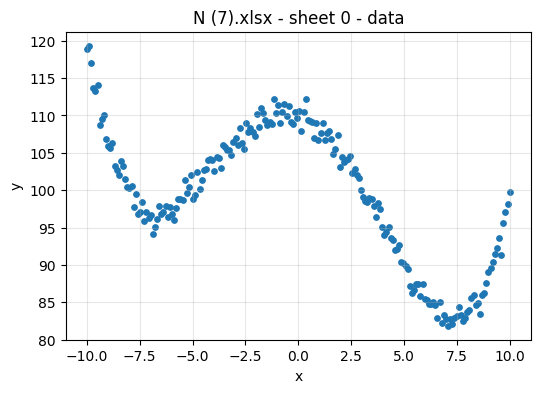

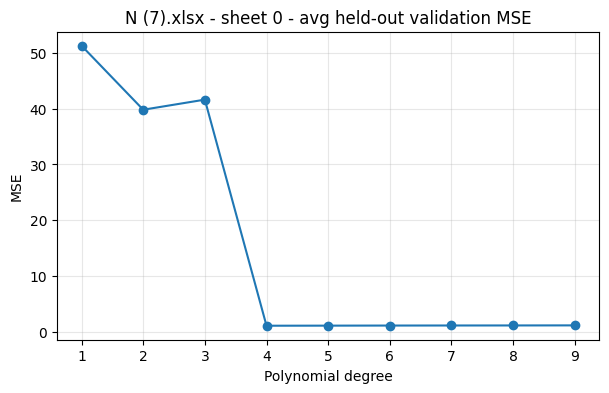

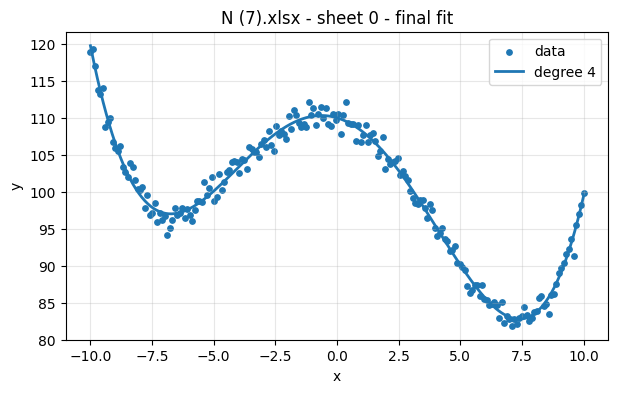


N (7).xlsx / sheet 1
Chosen degree counts across repeats: {9: 30}
Stable degree (most often chosen): 9
Best degree by average held-out validation MSE: 9
Average held-out validation MSE per degree:
  degree 1: 419.779059
  degree 2: 421.369684
  degree 3: 423.388587
  degree 4: 425.346650
  degree 5: 423.334082
  degree 6: 425.313126
  degree 7: 387.750748
  degree 8: 396.829853
  degree 9: 102.663573


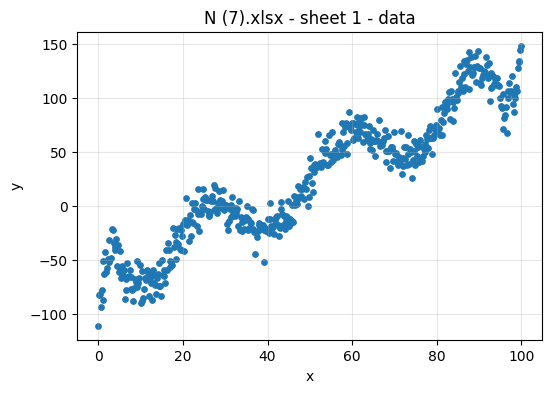

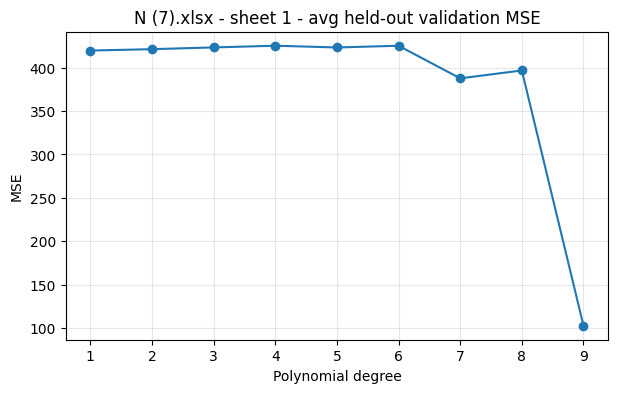

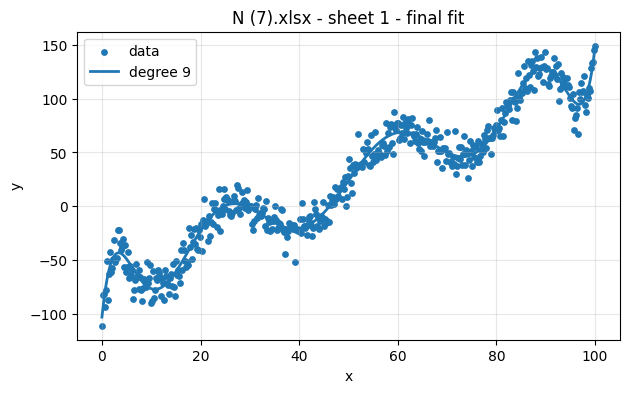


N (7).xlsx / sheet 2
Chosen degree counts across repeats: {6: 27, 8: 1, 7: 2}
Stable degree (most often chosen): 6
Best degree by average held-out validation MSE: 6
Average held-out validation MSE per degree:
  degree 1: 896.756220
  degree 2: 891.096893
  degree 3: 894.343139
  degree 4: 741.781318
  degree 5: 752.859987
  degree 6: 101.361923
  degree 7: 101.944125
  degree 8: 102.317532
  degree 9: 102.667733


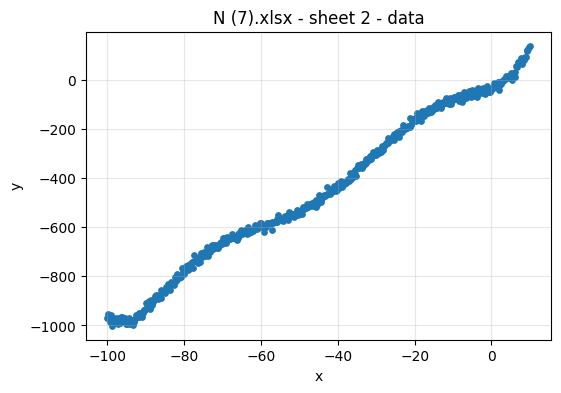

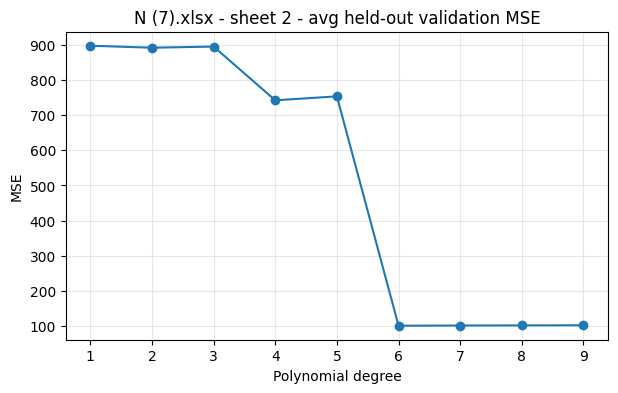

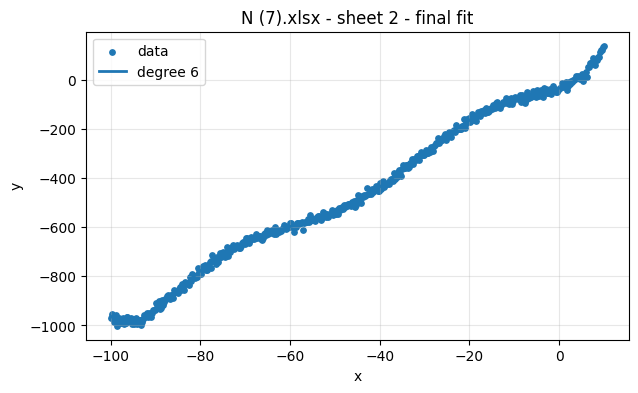


N (7).xlsx / sheet 3
Chosen degree counts across repeats: {4: 19, 6: 2, 8: 1, 7: 2, 5: 6}
Stable degree (most often chosen): 4
Best degree by average held-out validation MSE: 5
Average held-out validation MSE per degree:
  degree 1: 29.719317
  degree 2: 30.692057
  degree 3: 30.231857
  degree 4: 12.411080
  degree 5: 12.271605
  degree 6: 13.139779
  degree 7: 13.102243
  degree 8: 13.283300
  degree 9: 16.334312


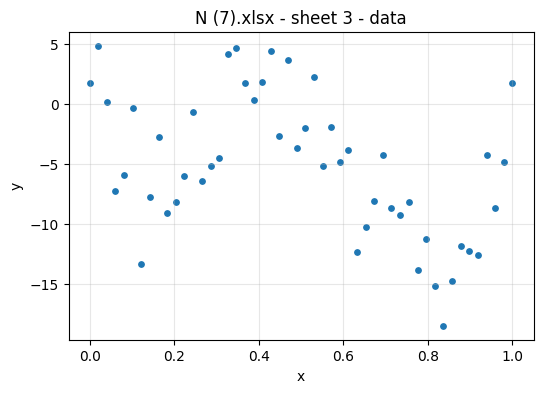

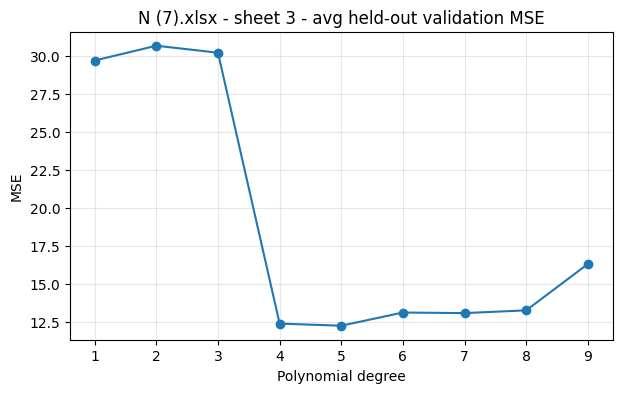

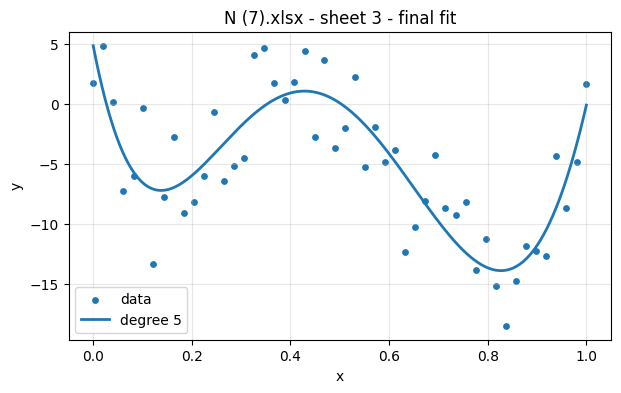


N (7).xlsx / sheet 4
Chosen degree counts across repeats: {9: 11, 8: 19}
Stable degree (most often chosen): 8
Best degree by average held-out validation MSE: 9
Average held-out validation MSE per degree:
  degree 1: 92.221677
  degree 2: 93.281130
  degree 3: 94.284636
  degree 4: 94.966598
  degree 5: 97.077048
  degree 6: 90.839162
  degree 7: 101.471146
  degree 8: 33.543373
  degree 9: 33.102529


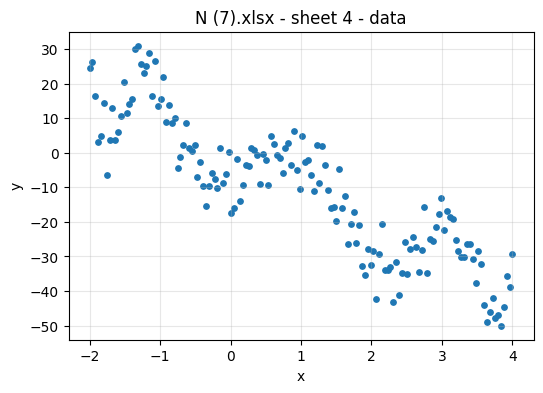

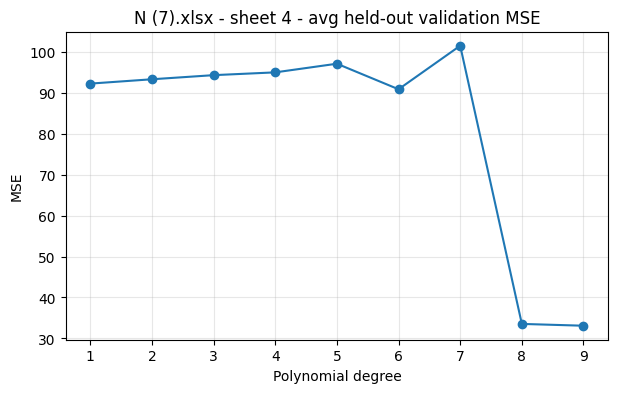

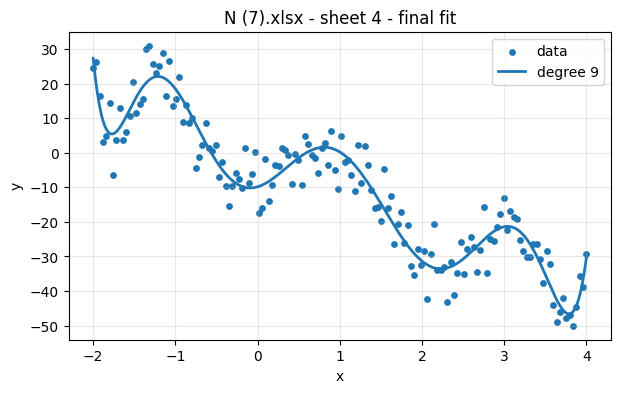


N (7).xlsx / sheet 5
Chosen degree counts across repeats: {7: 28, 8: 2}
Stable degree (most often chosen): 7
Best degree by average held-out validation MSE: 7
Average held-out validation MSE per degree:
  degree 1: 0.323001
  degree 2: 0.324207
  degree 3: 0.326106
  degree 4: 0.327831
  degree 5: 0.328065
  degree 6: 0.328979
  degree 7: 0.254297
  degree 8: 0.254711
  degree 9: 0.255701


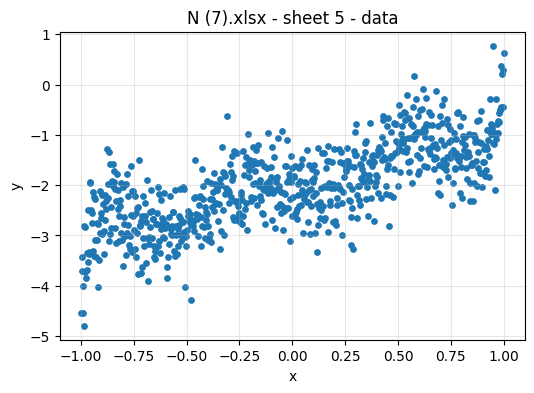

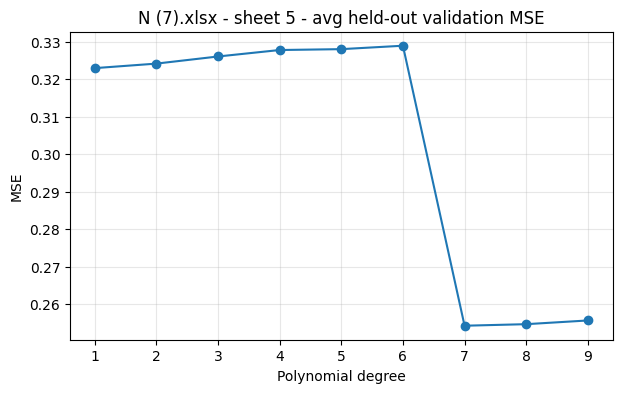

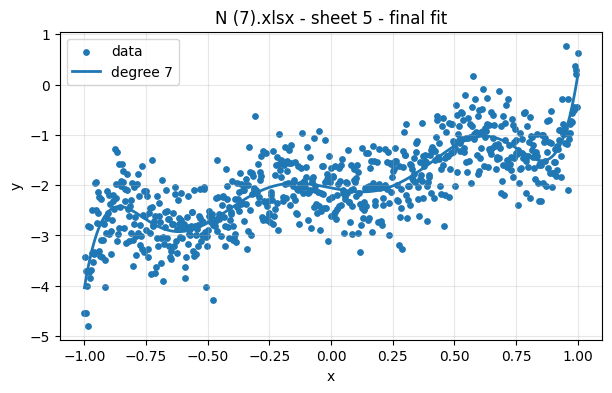


FINAL SUMMARY

E (7).xlsx
sheet 0: stable_degree=1, best_avg_val_degree=3
sheet 1: stable_degree=5, best_avg_val_degree=5
sheet 2: stable_degree=3, best_avg_val_degree=3
sheet 3: stable_degree=5, best_avg_val_degree=5
sheet 4: stable_degree=5, best_avg_val_degree=5
sheet 5: stable_degree=7, best_avg_val_degree=7

N (7).xlsx
sheet 0: stable_degree=4, best_avg_val_degree=4
sheet 1: stable_degree=9, best_avg_val_degree=9
sheet 2: stable_degree=6, best_avg_val_degree=6
sheet 3: stable_degree=4, best_avg_val_degree=5
sheet 4: stable_degree=8, best_avg_val_degree=9
sheet 5: stable_degree=7, best_avg_val_degree=7


In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import files

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# =========================
# 1) Upload Excel files
# =========================
uploaded = files.upload()

# =========================
# 2) Settings
# =========================
MAX_DEGREE = 9          # keep this low unless your teacher said otherwise
VAL_SIZE = 0.20         # outer validation split
N_REPEATS = 30          # repeat train/validation split for robustness
CV_FOLDS = 5            # inner CV on training set
RANDOM_SEED_BASE = 42   # reproducibility

# =========================
# 3) Helpers
# =========================
def prepare_xy(df):
    df = df.copy()

    # Keep numeric columns only
    df = df.select_dtypes(include=[np.number])

    # Need at least 2 numeric columns
    if df.shape[1] < 2:
        return None, None, None

    # Keep first two columns as x and y
    df = df.iloc[:, :2].copy()
    df.columns = ["x", "y"]

    # Remove NaN / inf
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    # Sort by x for clean plotting only
    df = df.sort_values("x").reset_index(drop=True)

    X = df[["x"]].values
    y = df["y"].values
    return df, X, y


def make_model(degree):
    # Scale x first, then create polynomial features, then fit linear regression.
    # Scaling improves numerical stability a lot.
    return Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", LinearRegression())
    ])


def choose_degree_nested_cv(X, y, max_degree=8, val_size=0.2, n_repeats=30, cv_folds=5, seed_base=42):
    """
    Repeated outer train/validation split.
    For each outer split:
      - choose degree via CV on training set only
      - refit on full training set
      - evaluate on held-out validation set

    Returns a robust summary of degree choice.
    """
    degree_counts = Counter()
    degree_val_mse = {d: [] for d in range(1, max_degree + 1)}
    chosen_degree_val_mse = []
    chosen_degree_cv_mse = []

    for r in range(n_repeats):
        seed = seed_base + r

        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=val_size, random_state=seed, shuffle=True
        )

        # Inner CV on training set only
        cv = KFold(n_splits=cv_folds, shuffle=True, random_state=seed)

        cv_means = []
        for d in range(1, max_degree + 1):
            model = make_model(d)
            scores = cross_val_score(
                model,
                X_train,
                y_train,
                scoring="neg_mean_squared_error",
                cv=cv
            )
            cv_means.append(-scores.mean())

        best_degree = int(np.argmin(cv_means)) + 1
        best_cv_mse = cv_means[best_degree - 1]
        degree_counts[best_degree] += 1
        chosen_degree_cv_mse.append(best_cv_mse)

        # Refit chosen degree on full training set, evaluate on validation set
        chosen_model = make_model(best_degree)
        chosen_model.fit(X_train, y_train)
        y_val_pred = chosen_model.predict(X_val)
        val_mse = mean_squared_error(y_val, y_val_pred)
        chosen_degree_val_mse.append(val_mse)

        # Also track validation performance of every degree on this same split
        for d in range(1, max_degree + 1):
            model = make_model(d)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            mse = mean_squared_error(y_val, y_pred)
            degree_val_mse[d].append(mse)

    # Degree chosen most often across repeats
    stable_degree = degree_counts.most_common(1)[0][0]

    # Degree with best average held-out validation MSE across repeats
    avg_val_mse_per_degree = {
        d: float(np.mean(mses)) for d, mses in degree_val_mse.items()
    }
    best_avg_val_degree = min(avg_val_mse_per_degree, key=avg_val_mse_per_degree.get)

    return {
        "degree_counts": degree_counts,
        "avg_val_mse_per_degree": avg_val_mse_per_degree,
        "stable_degree": stable_degree,
        "best_avg_val_degree": best_avg_val_degree,
        "mean_chosen_cv_mse": float(np.mean(chosen_degree_cv_mse)),
        "mean_chosen_val_mse": float(np.mean(chosen_degree_val_mse)),
    }


def analyze_sheet(df, filename, sheet_name):
    prepared = prepare_xy(df)
    if prepared[0] is None:
        print(f"{filename} / {sheet_name}: skipped (not enough numeric columns)")
        return None

    df_clean, X, y = prepared

    result = choose_degree_nested_cv(
        X, y,
        max_degree=MAX_DEGREE,
        val_size=VAL_SIZE,
        n_repeats=N_REPEATS,
        cv_folds=CV_FOLDS,
        seed_base=RANDOM_SEED_BASE
    )

    print(f"\n{filename} / sheet {sheet_name}")
    print("Chosen degree counts across repeats:", dict(result["degree_counts"]))
    print("Stable degree (most often chosen):", result["stable_degree"])
    print("Best degree by average held-out validation MSE:", result["best_avg_val_degree"])
    print("Average held-out validation MSE per degree:")
    for d in range(1, MAX_DEGREE + 1):
        print(f"  degree {d}: {result['avg_val_mse_per_degree'][d]:.6f}")

    # Plot raw data
    plt.figure(figsize=(6, 4))
    plt.scatter(df_clean["x"], df_clean["y"], s=15)
    plt.title(f"{filename} - sheet {sheet_name} - data")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot average validation MSE by degree
    degrees = list(range(1, MAX_DEGREE + 1))
    avg_mses = [result["avg_val_mse_per_degree"][d] for d in degrees]

    plt.figure(figsize=(7, 4))
    plt.plot(degrees, avg_mses, marker="o")
    plt.title(f"{filename} - sheet {sheet_name} - avg held-out validation MSE")
    plt.xlabel("Polynomial degree")
    plt.ylabel("MSE")
    plt.grid(True, alpha=0.3)
    plt.show()

    # Fit final model using the robust degree choice on all data, for visualization
    final_degree = result["best_avg_val_degree"]
    final_model = make_model(final_degree)
    final_model.fit(X, y)

    x_grid = np.linspace(df_clean["x"].min(), df_clean["x"].max(), 500).reshape(-1, 1)
    y_grid = final_model.predict(x_grid)

    plt.figure(figsize=(7, 4))
    plt.scatter(df_clean["x"], df_clean["y"], s=15, label="data")
    plt.plot(x_grid, y_grid, linewidth=2, label=f"degree {final_degree}")
    plt.title(f"{filename} - sheet {sheet_name} - final fit")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    return {
        "stable_degree": result["stable_degree"],
        "best_avg_val_degree": result["best_avg_val_degree"],
        "degree_counts": dict(result["degree_counts"]),
        "avg_val_mse_per_degree": result["avg_val_mse_per_degree"],
    }


# =========================
# 4) Process all files / sheets
# =========================
all_results = {}

for filename, file_bytes in uploaded.items():
    print("\n" + "=" * 60)
    print("FILE:", filename)
    print("=" * 60)

    xl = pd.ExcelFile(io.BytesIO(file_bytes))
    print("Sheets:", xl.sheet_names)

    file_results = {}
    for sheet_name in xl.sheet_names:
        df = pd.read_excel(io.BytesIO(file_bytes), sheet_name=sheet_name)
        res = analyze_sheet(df, filename, sheet_name)
        if res is not None:
            file_results[sheet_name] = res

    all_results[filename] = file_results

# =========================
# 5) Final compact summary
# =========================
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

for filename, file_results in all_results.items():
    print(f"\n{filename}")
    for sheet_name, res in file_results.items():
        print(
            f"sheet {sheet_name}: "
            f"stable_degree={res['stable_degree']}, "
            f"best_avg_val_degree={res['best_avg_val_degree']}"
        )